<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=299369841" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=299330267" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

📂 Lecture des données depuis : /kaggle/input/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset
✅ Classes détectées : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
📊 Nombre total d'images : 6400
🚀 DataLoaders prêts pour l'entraînement !


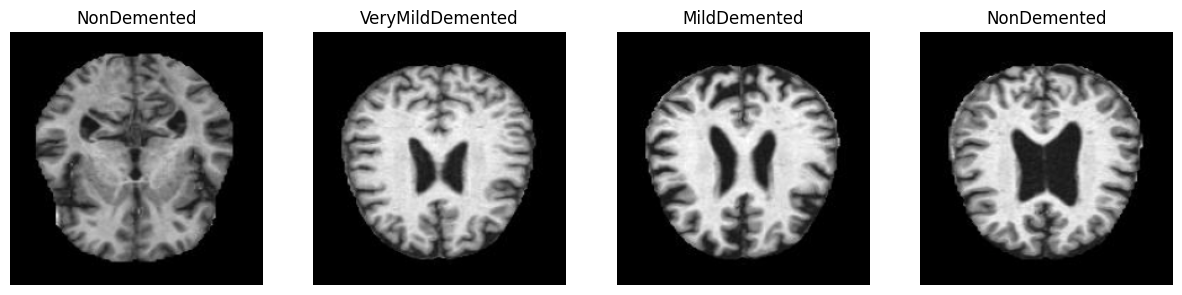

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# Chemin vers ton dataset
DATA_DIR = '/kaggle/input/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset'

BATCH_SIZE = 32
IMG_SIZE = 224  # Taille standard pour EfficientNet

print(f"📂 Lecture des données depuis : {DATA_DIR}")

# ==========================================
# 2. PRÉ-TRAITEMENT (PIPELINE)
# ==========================================
# On définit les transformations à appliquer à chaque image
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Redimensionner pour EfficientNet
    transforms.ToTensor(),                   # Convertir l'image (pixels 0-255) en Tenseur (0-1)
    # Normalisation standard (Moyenne et Écart-type d'ImageNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. CHARGEMENT DES DONNÉES
# ==========================================
try:
    # ImageFolder scanne automatiquement les sous-dossiers comme classes
    full_dataset = ImageFolder(root=DATA_DIR, transform=transform)
    
    # Afficher les classes trouvées
    classes = full_dataset.classes
    print(f"✅ Classes détectées : {classes}")
    print(f"📊 Nombre total d'images : {len(full_dataset)}")

    # Séparation Train (80%) / Val (20%)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Création des DataLoaders (C'est ce qui "nourrit" l'IA par petits lots)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print("🚀 DataLoaders prêts pour l'entraînement !")

except Exception as e:
    print(f"❌ Erreur lors du chargement : {e}")
    print("Conseil : Vérifie le chemin 'DATA_DIR' en haut du script.")

# ==========================================
# 4. VÉRIFICATION VISUELLE
# ==========================================
def imshow(img, title):
    # Dénormaliser pour l'affichage (revenir aux couleurs normales)
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

# Récupérer un lot d'images
if 'train_loader' in locals():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    # Afficher 4 images du lot
    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        imshow(images[i], classes[labels[i]])
    plt.show()

In [2]:
# Hi, it's Leila.
print(2**2)

4
